# IS 4487 Assignment 5: Exploratory Data Analysis (EDA) with Stakeholder Framing

In this assignment, you will:
- Load and explore a hotel bookings dataset
- Identify stakeholder needs and frame your analysis around business goals
- Practice data summarization and visualization
- Draw insights that could lead to actionable business recommendations

## Why This Matters

These skills are essential for business majors and minors working in areas like marketing, operations, finance, or consulting. Understanding how to explore and communicate data-driven insights helps you make better decisions and contribute to real-world business outcomes.

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_05_eda.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>


## Dataset Description: Hotel Bookings

This dataset contains booking information for two types of hotels: a **city hotel** and a **resort hotel**. Each record corresponds to a single booking and includes various details about the reservation, customer demographics, booking source, and whether the booking was canceled.

**Source**: [GitHub - TidyTuesday: Hotel Bookings](https://github.com/rfordatascience/tidytuesday/blob/master/data/2020/2020-02-11/readme.md)

### Key Use Cases
- Understand customer booking behavior
- Explore factors related to cancellations
- Segment guests based on booking characteristics
- Compare city vs. resort hotel performance

### Data Dictionary

| Variable | Type | Description |
|----------|------|-------------|
| `hotel` | character | Hotel type: City or Resort |
| `is_canceled` | integer | 1 = Canceled, 0 = Not Canceled |
| `lead_time` | integer | Days between booking and arrival |
| `arrival_date_year` | integer | Year of arrival |
| `arrival_date_month` | character | Month of arrival |
| `stays_in_weekend_nights` | integer | Nights stayed on weekends |
| `stays_in_week_nights` | integer | Nights stayed on weekdays |
| `adults` | integer | Number of adults |
| `children` | integer | Number of children |
| `babies` | integer | Number of babies |
| `meal` | character | Type of meal booked |
| `country` | character | Country code of origin |
| `market_segment` | character | Booking source (e.g., Direct, Online TA) |
| `distribution_channel` | character | Booking channel used |
| `is_repeated_guest` | integer | 1 = Repeated guest, 0 = New guest |
| `previous_cancellations` | integer | Past booking cancellations |
| `previous_bookings_not_canceled` | integer | Past bookings not canceled |
| `reserved_room_type` | character | Initially reserved room type |
| `assigned_room_type` | character | Room type assigned at check-in |
| `booking_changes` | integer | Number of booking modifications |
| `deposit_type` | character | Deposit type (No Deposit, Non-Refund, etc.) |
| `agent` | character | Agent ID who made the booking |
| `company` | character | Company ID (if booking through company) |
| `days_in_waiting_list` | integer | Days on the waiting list |
| `customer_type` | character | Booking type: Contract, Transient, etc. |
| `adr` | float | Average Daily Rate (price per night) |
| `required_car_parking_spaces` | integer | Requested parking spots |
| `total_of_special_requests` | integer | Number of special requests made |
| `reservation_status` | character | Final status (Canceled, No-Show, Check-Out) |
| `reservation_status_date` | date | Date of the last status update |

This dataset is ideal for classification, segmentation, and trend analysis exercises.


## 1. Setup and Data Loading

Instructions:
- Import `pandas`, `seaborn`, and `matplotlib.pyplot`.
- Import data from the hotels dataset into a dataframe (in GitHub go to the DataSets folder and look for `hotels.csv`)
- Display the first few rows to confirm it loaded correctly.


In [1]:
# Your code to import libraries and load data goes here
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

url = 'https://raw.githubusercontent.com/Stan-Pugsley/is_4487_base/main/DataSets/hotels.csv'
df = pd.read_csv(url)

# Confirm it loaded correctly
print(df.shape)
df.head()


(9404, 32)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


## 2. Stakeholder and Business Context

### Business framing:  

Every analysis should serve a decision-maker. Before you explore the data, identify who cares about hotel booking behavior and what they might want to know. Your analysis should be framed around those needs.

### Reflection: 
1. Who are the key stakeholders for this dataset?
2. What goals might each stakeholder have?
3. What is a clear, specific business problem statement that this data can help answer?





### ✍️ Your Response: 🔧
1. The key stakeholders are the hotel's **revenue manager** (sets room prices and decides how much to overbook), the **general manager and owners** (care about occupancy and profit), the **marketing and sales team** (decides which booking channels and guest segments to target), **front desk and operations** (plan staffing, rooms, parking and meals around expected arrivals), and **online travel agencies (OTAs) and travel agents** who send bookings and earn commission.

2. The revenue manager wants to maximize revenue per room by pricing each season correctly and predicting how many bookings will cancel. Owners want steady occupancy and fewer empty rooms caused by last-minute cancellations. Marketing wants to know which channels bring reliable, higher-paying guests so it can spend its budget there and build repeat business. Operations wants accurate headcounts so it doesn't overstaff or understaff. Travel agents want to keep their share of bookings and a good relationship with the hotel.

3. **Problem statement:** About 1 in 4 bookings at the resort hotel is canceled (24.8%), which leaves rooms empty that could have been sold. Which booking characteristics (lead time, market segment, deposit type, and customer type) are linked to higher cancellation rates, so the hotel can adjust its deposit policies, overbooking levels and channel strategy to reduce lost revenue?


## 3. Explore Data Structure and Quality

### Business framing:  

Before diving into analysis, analysts need to understand the shape and health of the data. Bad data leads to bad decisions.

### Do the following:
- Perform the following 3 checks to see the data quality:
  - Summary the data (e.g., `.info()`, `.describe()`)
  - Find the number of Null values
  - Find the number of duplicate row checks


In [2]:
# Add code here 🔧

# Check 1: Summary of the data
df.info()
df.describe()


<class 'pandas.DataFrame'>
RangeIndex: 9404 entries, 0 to 9403
Data columns (total 32 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           9404 non-null   str    
 1   is_canceled                     9404 non-null   int64  
 2   lead_time                       9404 non-null   int64  
 3   arrival_date_year               9404 non-null   int64  
 4   arrival_date_month              9404 non-null   str    
 5   arrival_date_week_number        9404 non-null   int64  
 6   arrival_date_day_of_month       9404 non-null   int64  
 7   stays_in_weekend_nights         9404 non-null   int64  
 8   stays_in_week_nights            9404 non-null   int64  
 9   adults                          9404 non-null   int64  
 10  children                        9404 non-null   int64  
 11  babies                          9404 non-null   int64  
 12  meal                            9404 non-null

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,9404.000000,9404.000000,9404.000000,9404.000000,9404.000000,9404.000000,9404.000000,9404.000000,9404.000000,9404.000000,9404.000000,9404.000000,9404.000000,9404.000000,7069.000000,1011.000000,9404.000000,9404.000000,9404.000000,9404.000000
mean,0.248299,79.326244,2015.156104,37.026584,15.515313,1.155040,3.078690,1.864738,0.095279,0.015419,0.077839,0.419715,0.290196,0.238622,200.990946,219.550940,1.019034,86.843614,0.144938,0.613143
std,0.432049,87.584146,0.443661,11.083421,9.025545,1.124304,2.379227,1.198565,0.393858,0.125781,0.267933,2.726546,1.352679,0.630041,80.330753,104.296474,10.137928,53.759940,0.353264,0.835930
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,9.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,8.000000,2015.000000,31.000000,7.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,156.000000,135.000000,0.000000,45.000000,0.000000,0.000000
50%,0.000000,48.000000,2015.000000,38.000000,16.000000,1.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,240.000000,223.000000,0.000000,71.550000,0.000000,0.000000
75%,0.000000,118.000000,2015.000000,45.000000,23.000000,2.000000,5.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,241.000000,286.000000,0.000000,120.600000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,13.000000,33.000000,55.000000,10.000000,2.000000,1.000000,26.000000,26.000000,17.000000,468.000000,511.000000,122.000000,508.000000,2.000000,5.000000


In [3]:
# Check 2: Number of null values in each column
nulls = df.isnull().sum()
print("Total missing values:", nulls.sum())
nulls[nulls > 0]


Total missing values: 10994


country     266
agent      2335
company    8393
dtype: int64

In [4]:
# Check 3: Number of duplicate rows
print("Duplicate rows:", df.duplicated().sum())
print("Share of rows that are duplicates:", round(df.duplicated().mean() * 100, 1), "%")


Duplicate rows: 1674
Share of rows that are duplicates: 17.8 %


In [5]:
# A few extra checks on values that look wrong
print("Hotel types in this file:", df['hotel'].unique())
print("Bookings with adr <= 0:", (df['adr'] <= 0).sum(), "| lowest adr:", df['adr'].min())
print("Bookings with 0 adults:", (df['adults'] == 0).sum())
print("Meal values:", df['meal'].unique())
print("reservation_status_date type:", df['reservation_status_date'].dtype)


Hotel types in this file: <StringArray>
['Resort Hotel']
Length: 1, dtype: str
Bookings with adr <= 0: 230 | lowest adr: -6.38
Bookings with 0 adults: 5
Meal values: <StringArray>
['BB', 'FB', 'HB', 'SC', 'Undefined']
Length: 5, dtype: str
reservation_status_date type: str


### Reflection:
1. Name at least one structure issue you’ve found (e.g., missing values, formatting problems).
2. How can you fix this structural issue?

### ✍️ Your Response: 🔧
1. The dataset has 9,404 rows and 32 columns, and I found several issues:
   - **Missing values:** `company` is missing in 8,393 rows (about 89%), `agent` in 2,335 rows, and `country` in 266 rows.
   - **Duplicates:** 1,674 rows (about 18%) are exact duplicates of another row.
   - **Formatting problems:** `agent` and `company` are ID codes but are stored as decimal numbers (floats), `reservation_status_date` is stored as text instead of a date, and `meal` has an "Undefined" category (258 rows).
   - **Invalid values:** one booking has a negative average daily rate (-6.38), 230 bookings have an `adr` of 0 or less, and 5 bookings have 0 adults.
   - **Scope:** even though the data dictionary describes a city hotel and a resort hotel, this file only contains the **Resort Hotel**, and most arrivals are from July–December 2015, so I can't compare the two hotel types or look at a full year.

2. Fixes:
   - For `company` and `agent`, missing most likely means "no company or agent was used," so I would fill them with 0 or "None" (or turn them into a yes/no flag) and convert the IDs to text. For `country`, I would fill missing values with "Unknown."
   - Remove the duplicate rows with `df.drop_duplicates()` after confirming they aren't separate bookings that happen to look identical (the dataset has no booking ID, so some could be real group bookings). Removing them drops the cancellation rate from 24.8% to about 17.7%, so this choice matters.
   - Convert `reservation_status_date` with `pd.to_datetime()`, and treat "Undefined" meals as missing or group them with "SC" (no meal package).
   - Remove or flag the negative `adr` and the 0-adult bookings. Keep the ＄0 bookings only if they are complimentary stays, since those are real bookings but not revenue.


## 4. Univariate Analysis

### Business framing:  

Hotels care about trends like average stay length, customer mix, and pricing. A good EDA starts with understanding single variables and their distribution.

### Do the following:
- Select at least 3 individual variables to explore
- Use plots and summary methods (e.g. info(), describe(), etc)  to describe the distribution (hint: we are only looking at the values of one variable, so think of plots you've used in the past that DON'T compare 2 variables.)
- Focus on what matters from a business standpoint (e.g., pricing, cancellations, guest types)

count    9404.00
mean       86.84
std        53.76
min        -6.38
25%        45.00
50%        71.55
75%       120.60
max       508.00
Name: adr, dtype: float64


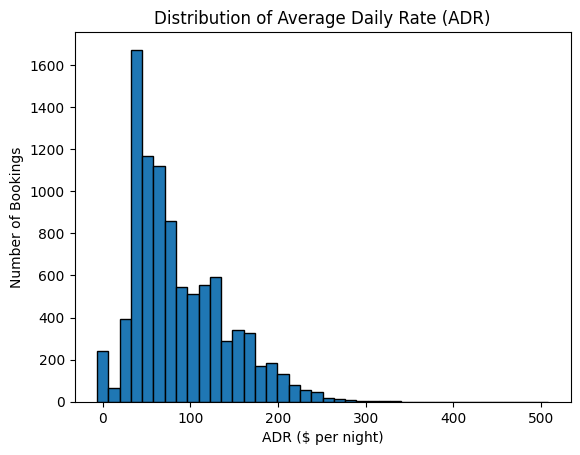

In [6]:
# Your code for univariate analysis (e.g., plots, value counts) 🔧

# Variable 1: adr (Average Daily Rate = price per night)
print(df['adr'].describe().round(2))

plt.hist(df['adr'], bins=40, edgecolor='black')
plt.title("Distribution of Average Daily Rate (ADR)")
plt.xlabel("ADR ($ per night)")
plt.ylabel("Number of Bookings")
plt.show()


count    9404.0
mean       79.3
std        87.6
min         0.0
25%         8.0
50%        48.0
75%       118.0
max       737.0
Name: lead_time, dtype: float64


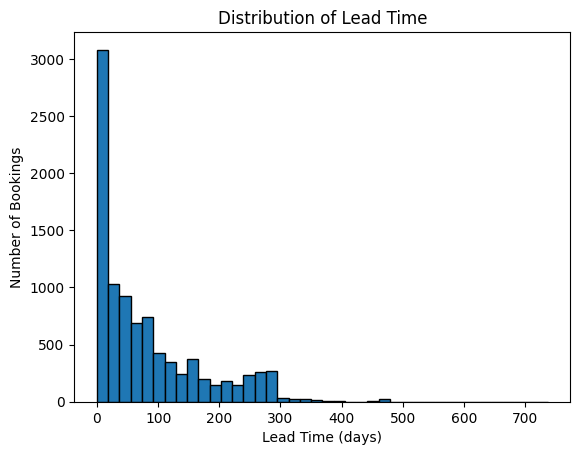

In [7]:
# Variable 2: lead_time (days between booking and arrival)
print(df['lead_time'].describe().round(1))

plt.hist(df['lead_time'], bins=40, edgecolor='black')
plt.title("Distribution of Lead Time")
plt.xlabel("Lead Time (days)")
plt.ylabel("Number of Bookings")
plt.show()


market_segment
Online TA        3341
Offline TA/TO    2169
Direct           1658
Groups           1296
Corporate         899
Complementary      41
Name: count, dtype: int64
market_segment
Online TA        35.5
Offline TA/TO    23.1
Direct           17.6
Groups           13.8
Corporate         9.6
Complementary     0.4
Name: proportion, dtype: float64


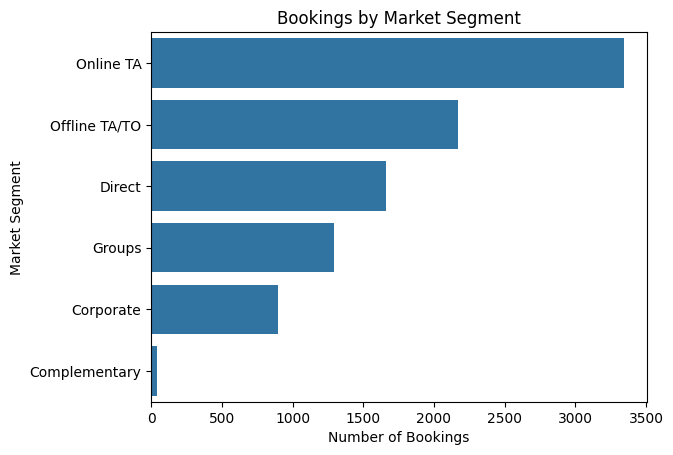

In [8]:
# Variable 3: market_segment (where the booking came from)
print(df['market_segment'].value_counts())
print((df['market_segment'].value_counts(normalize=True) * 100).round(1))

sns.countplot(y='market_segment', data=df, order=df['market_segment'].value_counts().index)
plt.title("Bookings by Market Segment")
plt.xlabel("Number of Bookings")
plt.ylabel("Market Segment")
plt.show()


is_canceled
0    7069
1    2335
Name: count, dtype: int64
Cancellation rate: 24.8 %


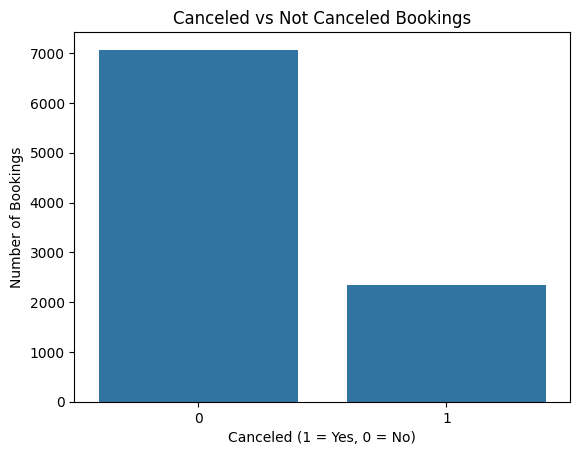

In [9]:
# Extra: overall cancellation rate (the key outcome for the business problem)
print(df['is_canceled'].value_counts())
print("Cancellation rate:", round(df['is_canceled'].mean() * 100, 1), "%")

sns.countplot(x='is_canceled', data=df)
plt.title("Canceled vs Not Canceled Bookings")
plt.xlabel("Canceled (1 = Yes, 0 = No)")
plt.ylabel("Number of Bookings")
plt.show()


### Reflection:
1. Variable 1 – What did you explore and what did you find?
2. Variable 2 – What did you explore and what did you find?
3. Variable 3 – What did you explore and what did you find?

### ✍️ Your Response: 🔧
- **Variable 1 – Summary and insights:** I explored `adr` (the average price per night) with `.describe()` and a histogram. The median rate is about ＄72, and the mean is higher at about ＄87, so the distribution is right-skewed: most bookings are between ＄45 and ＄121, with a long tail of expensive stays up to ＄508. There are also about 230 bookings at ＄0 or below (including one negative rate), which are either free or complimentary stays or data errors. For the revenue manager, this means the median is a better "typical price" than the mean, and the high-rate bookings (mostly in peak summer) are worth studying separately.
- **Variable 2 – Summary and insights:** I explored `lead_time` with `.describe()` and a histogram. It is heavily right-skewed: the median is 48 days, but the mean is 79 days and the maximum is 737 days (more than two years ahead). About a quarter of bookings are made within 8 days of arrival, so the hotel receives a lot of last-minute business as well as some very early bookings. This matters because bookings made far in advance have more time to be canceled.
- **Variable 3 – Summary and insights:** I explored `market_segment` with value counts and a count plot. Online travel agencies (Online TA) bring in the most bookings (35.5%), followed by offline travel agents/tour operators (23.1%), direct bookings (17.6%), groups (13.8%) and corporate (9.6%). That means almost 60% of the hotel's business comes through third-party agents that charge commission, so growing direct bookings could improve profit. I also checked `is_canceled`: 2,335 of 9,404 bookings (24.8%) were canceled.


## 5. Bivariate Analysis

### Business framing:  

Stakeholders often ask: “What drives cancellations?” or “Do longer stays mean higher revenue?” Bivariate analysis helps you uncover those kinds of relationships.

### Do the following:
- Choose 2 relevant variable pairs (e.g., `lead_time` vs. `is_canceled`, or `adr` vs. `customer_type`)
- Use scatterplots, grouped bar plots, or boxplots to explore the relationships
- Interpret what these relationships could mean for the hotel business

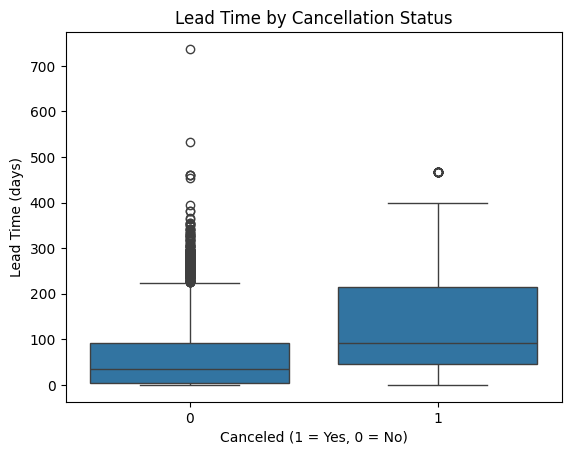

              mean  median
is_canceled               
0             64.0    34.0
1            126.0    93.0


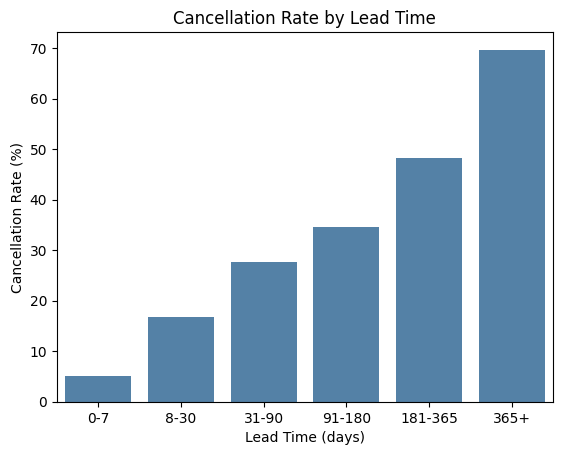

lead_time
0-7         5.2
8-30       16.7
31-90      27.7
91-180     34.5
181-365    48.3
365+       69.7
Name: is_canceled, dtype: float64

In [10]:
# Your code to analyze variable relationships (e.g., scatterplots, grouped bars) 🔧

# Relationship 1: lead_time vs is_canceled
sns.boxplot(x='is_canceled', y='lead_time', data=df)
plt.title("Lead Time by Cancellation Status")
plt.xlabel("Canceled (1 = Yes, 0 = No)")
plt.ylabel("Lead Time (days)")
plt.show()

print(df.groupby('is_canceled')['lead_time'].agg(['mean', 'median']).round(0))

# Cancellation rate by lead time range
lead_bins = pd.cut(df['lead_time'], bins=[-1, 7, 30, 90, 180, 365, 800],
                   labels=['0-7', '8-30', '31-90', '91-180', '181-365', '365+'])
cancel_by_lead = df.groupby(lead_bins, observed=True)['is_canceled'].mean() * 100

sns.barplot(x=cancel_by_lead.index, y=cancel_by_lead.values, color='steelblue')
plt.title("Cancellation Rate by Lead Time")
plt.xlabel("Lead Time (days)")
plt.ylabel("Cancellation Rate (%)")
plt.show()

cancel_by_lead.round(1)


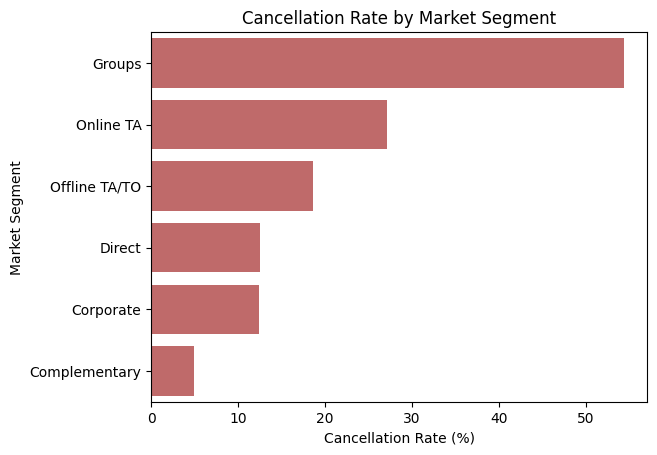

market_segment
Groups           54.3
Online TA        27.1
Offline TA/TO    18.6
Direct           12.5
Corporate        12.3
Complementary     4.9
Name: is_canceled, dtype: float64

In [11]:
# Relationship 2: market_segment vs is_canceled
cancel_by_segment = (df.groupby('market_segment')['is_canceled'].mean() * 100).sort_values(ascending=False)

sns.barplot(x=cancel_by_segment.values, y=cancel_by_segment.index, color='indianred')
plt.title("Cancellation Rate by Market Segment")
plt.xlabel("Cancellation Rate (%)")
plt.ylabel("Market Segment")
plt.show()

cancel_by_segment.round(1)


In [12]:
# Supporting check: cancellation rate by deposit type
print(df.groupby('deposit_type')['is_canceled'].agg(['mean', 'count']).round(3))


               mean  count
deposit_type              
No Deposit    0.199   8816
Non Refund    0.986    585
Refundable    0.000      3


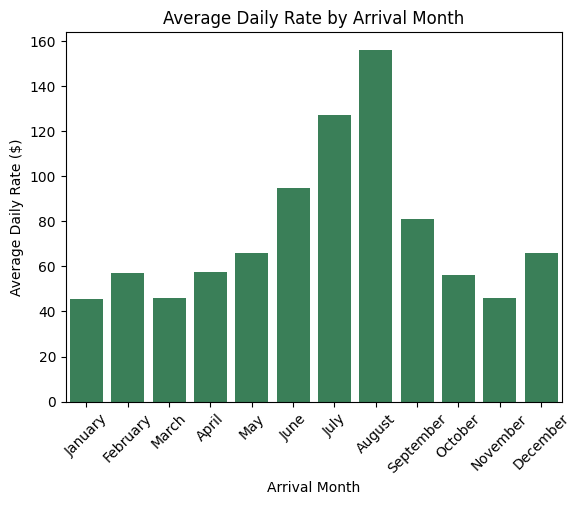

arrival_date_month
January       46.0
February      57.0
March         46.0
April         58.0
May           66.0
June          95.0
July         127.0
August       156.0
September     81.0
October       56.0
November      46.0
December      66.0
Name: adr, dtype: float64
                    mean  count
is_repeated_guest              
0                  0.260   8672
1                  0.115    732


In [13]:
# Supporting checks used in the final takeaways
# Average daily rate by arrival month (seasonality)
month_order = ['January','February','March','April','May','June','July',
               'August','September','October','November','December']
adr_by_month = df.groupby('arrival_date_month')['adr'].mean().reindex(month_order)

sns.barplot(x=adr_by_month.index, y=adr_by_month.values, color='seagreen')
plt.title("Average Daily Rate by Arrival Month")
plt.xlabel("Arrival Month")
plt.ylabel("Average Daily Rate ($)")
plt.xticks(rotation=45)
plt.show()
print(adr_by_month.round(0))

# Cancellation rate for repeat vs new guests
print(df.groupby('is_repeated_guest')['is_canceled'].agg(['mean', 'count']).round(3))


### Reflection:
1. Relationship 1 – What did you analyze and what insights did you find?
2. Relationship 2 – What did you analyze and what insights did you find?

### ✍️ Your Response: 🔧
- **Relationship 1:** I analyzed `lead_time` vs. `is_canceled` using a boxplot and a bar chart of cancellation rate by lead time range. Canceled bookings were made much further in advance (median of 93 days vs. 34 days for bookings that weren't canceled). The cancellation rate climbs steadily with lead time: about 5% for bookings made within a week of arrival, 28% at 31–90 days, 48% at 181–365 days, and about 70% for bookings made more than a year out (only 33 bookings). For the hotel, this means long-lead bookings are the riskiest. It could ask for deposits or send reminder and confirmation emails for early bookings, and it can safely overbook more for dates that have many long-lead reservations.
- **Relationship 2:** I analyzed `market_segment` vs. `is_canceled` using a bar chart of cancellation rates. Group bookings cancel the most (54%), followed by Online TA (27%) and Offline TA/TO (19%). Direct (12.5%) and Corporate (12%) bookings are the most reliable. I also checked deposit type: almost all "Non Refund" bookings (98.6%) were canceled, which is surprising. It likely reflects how group and tour-operator blocks are recorded in the data rather than guests giving up money, so this is worth investigating before changing policy. Overall, the channels that bring the most volume (OTAs and groups) also bring the most cancellations, while direct guests are more dependable.


## 6. Problem Complexity and Analytics Framing

### Business framing:  

Let’s say you found a strong trend — maybe high lead times predict cancellations, or certain channels bring repeat guests. What kind of problem is this?

- Choose one insight from your earlier analysis
- Reflect on:
  - What type of complexity this problem represents (e.g., variety, volume, variability)
  - What kind of analytics would help solve or explain it (descriptive, diagnostic, predictive, prescriptive)

### Reflection: 
1. What was your selected insight?
2. What kind of complexity does it involve?
3. What type of analytics would help, and why?



### ✍️ Your Response: 🔧
1. **Selected insight:** Bookings with longer lead times are much more likely to be canceled. The cancellation rate rises from about 5% for bookings made within a week to about 48% for bookings made 6–12 months out, and group and OTA bookings cancel more than direct bookings.
2. **Complexity:** This problem mainly involves **variability** and **variety**. Variability: cancellation risk changes a lot with lead time, season, and channel, and a single booking's outcome isn't known until close to the arrival date. Variety: the answer depends on many different kinds of data at once, including numbers (lead time, rate), categories (market segment, deposit type, customer type), guest history (previous cancellations, repeat guest) and dates. The data quality issues (duplicates, missing agent and company IDs) add further complexity. **Volume** is less of an issue here, since there are fewer than 10,000 rows.
3. **Type of analytics:** **Predictive analytics** would help most. A classification model (like logistic regression or a decision tree) could use lead time, market segment, deposit type, customer type and special requests to estimate each new booking's probability of cancellation. The EDA we did here is **descriptive** (what happened) and a little **diagnostic** (why it happened). Once we have predictions, **prescriptive** analytics could recommend actions, such as how many extra rooms to overbook for a given date or which bookings should require a deposit.


## 7. Final Takeaways and Recommendations

### Business framing:  

Imagine you’re preparing for a stakeholder meeting. What would you highlight from your findings?

### Reflection: 
- 1. What patterns or trends stood out?
- 2. How do they connect to stakeholder goals?
- 3. What recommendation would you make based on this analysis?
- 4. How does this relate to your customized learning outcome you created in canvas?



### ✍️ Your Response: 🔧

1. **Patterns that stood out:** About 1 in 4 bookings at the resort is canceled. Cancellations rise sharply with lead time (about 5% for bookings made within a week vs. about 48% for 6–12 months out). Group bookings (54%) and online travel agency bookings (27%) cancel far more than direct (12.5%) and corporate (12%) bookings. Prices are highly seasonal: the average daily rate peaks in August (about ＄156) and drops to about ＄46 in January, March and November. Repeat guests cancel much less (about 12% vs. 26% for new guests), but they are only about 8% of bookings.

2. **Connection to stakeholder goals:** The revenue manager and owners want to fill rooms at the best price. Knowing which bookings are likely to cancel helps them overbook safely and avoid empty rooms in peak season when rates are highest. Marketing can use the channel results to shift effort toward direct and repeat guests, who are more reliable and don't cost agent commission. Operations benefits from more accurate expected arrivals for staffing.

3. **Recommendation:** Introduce a small deposit or a stricter cancellation window for bookings made more than 90 days in advance and for group and OTA bookings, especially during the July–September peak. At the same time, invest in direct booking and a loyalty/repeat-guest offer (for example, a member rate on the hotel website) to grow the low-cancellation segments. Before making policy changes, the hotel should clean the data (remove duplicates and check the Non Refund records) and build a predictive cancellation model to set overbooking levels by date.

4. **Connection to my learning outcome:** My customized learning outcomes in Canvas focused on building skills in Python and AI and applying them to accounting and business decisions. This assignment used Python (pandas, seaborn, matplotlib) to clean, summarize and visualize real data, and I used AI to help write and troubleshoot the code, which is the workflow I set as a goal. The analysis also ties to accounting: cancellations directly affect revenue recognition and forecasting, and turning booking data into revenue insights is the kind of analysis I want to be able to do in my career.


## Submission Instructions

✅ **Before submitting:**
- Make sure all code cells are run and outputs are visible  
- All markdown questions are answered thoughtfully  
- Submit the assignment as an **HTML file** on Canvas


In [ ]:
!jupyter nbconvert --to html "assignment_05_eda.ipynb"